<a href="https://colab.research.google.com/github/ParidhiiJ8/Placement_predict/blob/main/Placement_predicter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

In [165]:
df = pd.read_csv("/content/college_student_placement_dataset.csv")

In [166]:
df.shape

(10000, 10)

In [167]:
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [168]:
df.duplicated().sum()

np.int64(0)

In [169]:
df.isnull().sum()

,0
College_ID,0
IQ,0
Prev_Sem_Result,0
CGPA,0
Academic_Performance,0
Internship_Experience,0
Extra_Curricular_Score,0
Communication_Skills,0
Projects_Completed,0
Placement,0


In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [171]:
df = df.iloc[: ,1:]

In [172]:
df.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,No,8,8,4,No
1,97,5.52,5.37,8,No,7,8,0,No
2,109,5.36,5.83,9,No,3,1,1,No
3,122,5.47,5.75,6,Yes,1,6,1,No
4,96,7.91,7.69,7,No,8,10,2,No


In [173]:
df.columns

Index(['IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement'],
      dtype='object')

In [174]:
colors = df["Placement"].map({"Yes":"Green", "No": "Red"})

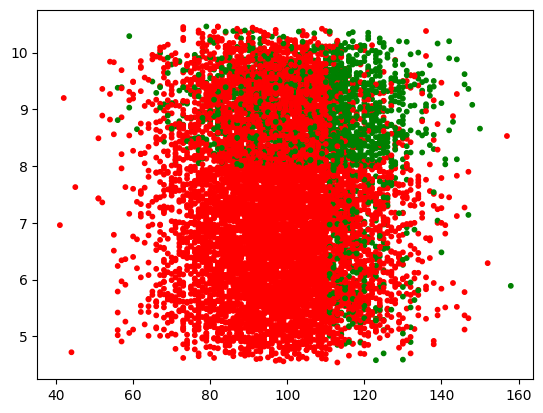

In [175]:
plt.scatter(df['IQ'], df['CGPA'],c= colors, s=10)

In [176]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Placement_encoded'] = le.fit_transform(df['Placement'])


In [177]:
df['Placement']

,Placement
0,No
1,No
2,No
3,No
4,No
...,...
9995,Yes
9996,No
9997,No
9998,No


In [178]:
df['Placement_encoded']

,Placement_encoded
0,0
1,0
2,0
3,0
4,0
...,...
9995,1
9996,0
9997,0
9998,0


In [179]:
df = pd.get_dummies(
    df,
    columns=['Internship_Experience'],
    drop_first=True,
    dtype=int
)

In [180]:
df.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement,Placement_encoded,Internship_Experience_Yes
0,107,6.61,6.28,8,8,8,4,No,0,0
1,97,5.52,5.37,8,7,8,0,No,0,0
2,109,5.36,5.83,9,3,1,1,No,0,0
3,122,5.47,5.75,6,1,6,1,No,0,1
4,96,7.91,7.69,7,8,10,2,No,0,0


In [181]:
df = df.drop(columns = ['Placement'])

In [182]:
col = df.pop('Placement_encoded')
df['Placement_encoded'] = col
df

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Internship_Experience_Yes,Placement_encoded
0,107,6.61,6.28,8,8,8,4,0,0
1,97,5.52,5.37,8,7,8,0,0,0
2,109,5.36,5.83,9,3,1,1,0,0
3,122,5.47,5.75,6,1,6,1,1,0
4,96,7.91,7.69,7,8,10,2,0,0
...,...,...,...,...,...,...,...,...,...
9995,119,8.41,8.29,4,1,8,0,0,1
9996,70,9.25,9.34,7,0,7,2,0,0
9997,89,6.08,6.25,3,3,9,5,1,0
9998,107,8.77,8.92,3,7,5,1,0,0


In [183]:
#now we use logistic regression because lg iss used to give the output probably based and it is used for binary classification so this is used


<Axes: xlabel='IQ', ylabel='CGPA'>

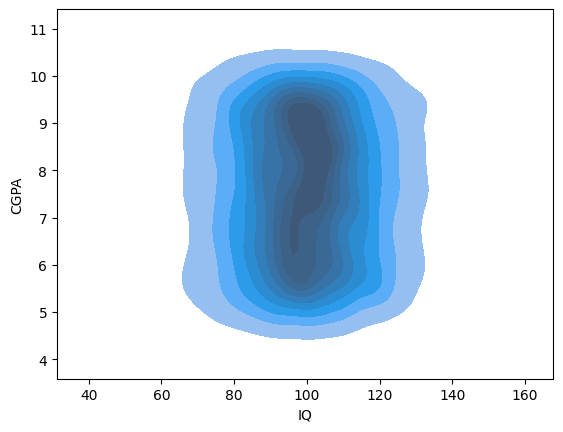

In [184]:
sns.kdeplot(
    data=df,
    x='IQ',
    y='CGPA',
    fill=True
)

<Axes: >

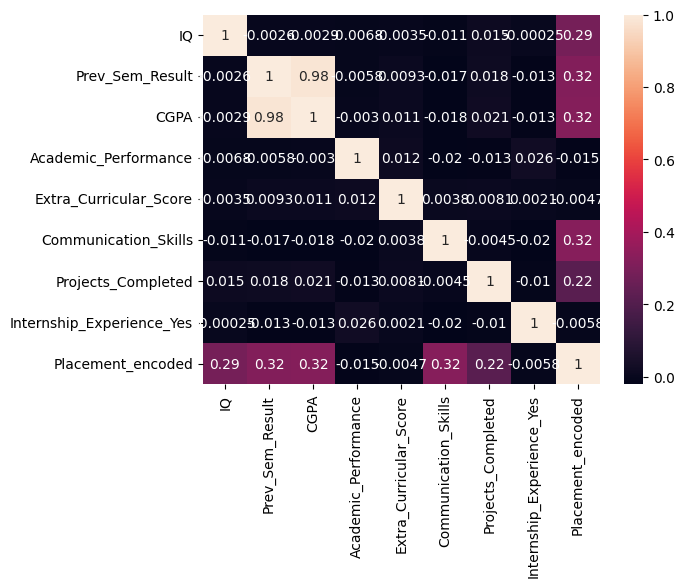

In [185]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

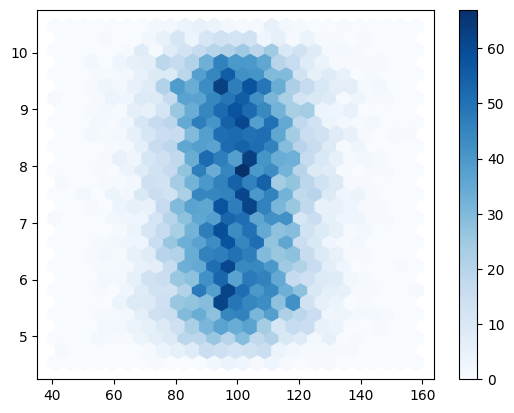

In [186]:
plt.hexbin(
    df['IQ'],
    df['CGPA'],
    gridsize=25,
    cmap='Blues'
)
plt.colorbar()

In [187]:
X = df.iloc[:, 0:8]

In [188]:
X

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Internship_Experience_Yes
0,107,6.61,6.28,8,8,8,4,0
1,97,5.52,5.37,8,7,8,0,0
2,109,5.36,5.83,9,3,1,1,0
3,122,5.47,5.75,6,1,6,1,1
4,96,7.91,7.69,7,8,10,2,0
...,...,...,...,...,...,...,...,...
9995,119,8.41,8.29,4,1,8,0,0
9996,70,9.25,9.34,7,0,7,2,0
9997,89,6.08,6.25,3,3,9,5,1
9998,107,8.77,8.92,3,7,5,1,0


In [189]:
Y = df.iloc[:, -1:]

In [190]:
Y

,Placement_encoded
0,0
1,0
2,0
3,0
4,0
...,...
9995,1
9996,0
9997,0
9998,0


In [191]:
from sklearn.model_selection import train_test_split

x_train,  x_test,y_train, y_test = train_test_split(X,Y, random_state= 42, test_size=0.2)

In [192]:
x_train

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Internship_Experience_Yes
9254,103,7.30,6.96,10,6,6,1,0
1561,88,5.49,5.02,3,2,4,1,1
1670,96,6.86,6.99,4,9,5,4,0
6087,76,6.09,6.22,2,6,7,1,1
6669,110,8.19,8.06,2,1,1,2,1
...,...,...,...,...,...,...,...,...
5734,91,9.93,9.72,6,8,8,1,0
5191,99,7.74,7.36,9,7,10,0,0
5390,89,7.07,6.66,1,10,1,5,1
860,103,7.74,7.57,4,8,3,2,0


In [193]:
y_train

,Placement_encoded
9254,0
1561,0
1670,0
6087,0
6669,0
...,...
5734,0
5191,0
5390,0
860,0


In [194]:
x_test

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Internship_Experience_Yes
6252,139,7.29,7.24,8,8,4,4,0
4684,84,8.28,8.49,8,3,3,5,1
1731,94,5.26,5.66,8,7,10,4,0
4742,100,6.22,6.29,6,8,6,3,1
4521,116,5.99,6.39,6,2,9,5,0
...,...,...,...,...,...,...,...,...
6412,72,7.53,7.40,3,6,8,3,0
8285,114,8.15,7.95,8,6,3,2,1
7853,108,8.85,8.81,3,6,9,1,1
1095,98,9.89,9.63,1,3,1,0,0


In [195]:
y_test

,Placement_encoded
6252,0
4684,0
1731,0
4742,0
4521,1
...,...
6412,0
8285,0
7853,0
1095,0


In [196]:
from sklearn.preprocessing import StandardScaler

sc= StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [197]:
# we have done this just to change the shape of y_train from (8000,1) to (8000,) => basically converting from 2d array to 1d array
y_train.shape

(8000, 1)

In [198]:
y_train = np.ravel(y_train)

In [199]:

y_train.shape

(8000,)

In [200]:
#logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(x_train,y_train)

LogisticRegression()

In [201]:
y_pred = model.predict(x_test)

In [202]:
from sklearn.metrics import accuracy_score

In [203]:
accuracy_score(y_pred, y_test)

0.9035

In [213]:
type(x_train)

numpy.ndarray

In [214]:
type(y_train)

numpy.ndarray

In [204]:
#random forest

from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators = 100, random_state =42)
rfc.fit(x_train,y_train)

y_pred_rfc = rfc.predict(x_test)


In [205]:
accuracy_score(y_pred_rfc, y_test)


1.0

In [208]:
#svm

from sklearn.svm import SVC
svc = SVC(kernel = 'rbf', C=1.0, gamma = 'scale')
svc.fit(x_train,y_train)

y_pred_svm = svc.predict(x_test)

In [209]:
accuracy_score(y_pred_svm, y_test)

0.949

In [216]:
import pickle

In [218]:
pickle.dump(model, open('model.pkl', 'wb'))